# ECUACIÓN LOGÍSTICA

## Ajuste para los parámetros **k** y **r**

In [1]:
from scipy.optimize import curve_fit
x = []
y = []

with open('poblacion.txt', 'r') as file:
    for linea in file:
        partes = linea.strip().split("\t")
        if len(partes) == 2:
            año = int(partes[0])
            valor = int(partes[1])
            x.append(año)
            y.append(valor)

if len(x) == len(y):
    print("Los datos se han leído correctamente.")



Los datos se han leído correctamente.


In [2]:
import numpy as np
def solucion_analitica(t,k,r):
    numerador = y[0] * k
    denominador = y[0] + ((k-y[0]) * np.exp(-r*(t - x[0])))
    return numerador / denominador

K = 1.36066e+10 ± 1.50596e+08
r = 0.0259688 ± 0.000150589


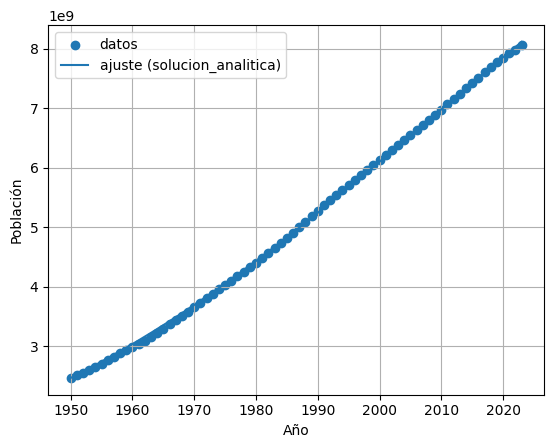

In [3]:
# --- ajuste con curve_fit ---
import matplotlib.pyplot as plt
x = np.array(x)
y = np.array(y)

p0 = [3e9, 0.02]

# opcional: forzar que k y r sean positivos
bounds = (0, np.inf)

popt, pcov = curve_fit(solucion_analitica, x, y, p0=p0, bounds=bounds)
k_opt, r_opt = popt
perr = np.sqrt(np.diag(pcov))   # errores estándar de los parámetros

print(f"K = {k_opt:.6g} ± {perr[0]:.6g}")
print(f"r = {r_opt:.6g} ± {perr[1]:.6g}")

# --- graficar datos y ajuste ---
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = solucion_analitica(x_fit, k_opt, r_opt)

plt.scatter(x, y, label='datos')
plt.plot(x_fit, y_fit, label='ajuste (solucion_analitica)')
plt.xlabel('Año')
plt.ylabel('Población')
plt.legend()
plt.grid(True)
plt.show()

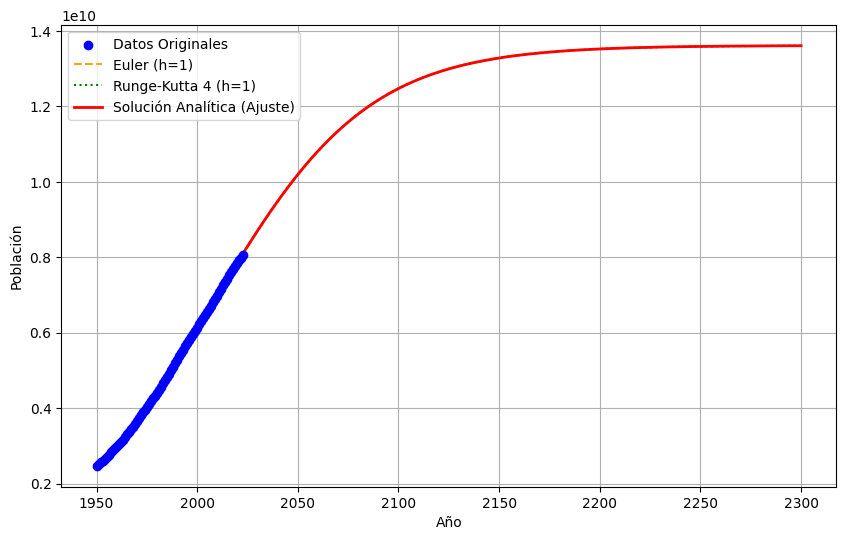

In [4]:
#Euler y Runge-Kutta

def f(t, y, k, r):
    """Define la ecuación diferencial logística."""
    dydt = r * y * (1 - y / k)
    return dydt

def metodo_euler(f, y0, t_span, h, k, r):
    """
    Resuelve la EDO usando el método de Euler.
    
    y0: condición inicial y(t0)
    t_span: [t_inicio, t_final]
    h: tamaño del paso
    k, r: parámetros de la EDO
    """
    t_valores = np.arange(t_span[0], t_span[1] + h, h)
    y_valores = np.zeros(len(t_valores))
    
    y_valores[0] = y0  # Establecer condición inicial
    
    for i in range(len(t_valores) - 1):
        t = t_valores[i]
        y = y_valores[i]
        
        y_siguiente = y + h * f(t, y, k, r)
        y_valores[i+1] = y_siguiente
        
    return t_valores, y_valores

def metodo_rk4(f, y0, t_span, h, k, r):
    """
    Resuelve la EDO usando el método de Runge-Kutta de 4to orden.
    """
    t_valores = np.arange(t_span[0], t_span[1] + h, h)
    y_valores = np.zeros(len(t_valores))
    
    y_valores[0] = y0
    
    for i in range(len(t_valores) - 1):
        t = t_valores[i]
        y = y_valores[i]
        
        k1 = h * f(t, y, k, r)
        k2 = h * f(t + 0.5 * h, y + 0.5 * k1, k, r)
        k3 = h * f(t + 0.5 * h, y + 0.5 * k2, k, r)
        k4 = h * f(t + h, y + k3, k, r)
        
        y_siguiente = y + (k1 + 2*k2 + 2*k3 + k4) / 6.0
        y_valores[i+1] = y_siguiente
        
    return t_valores, y_valores

# --- Asumiendo que ya corriste tu 'curve_fit' ---

# k_opt, r_opt = popt  (De tu código anterior)
# x = np.array(x)      (De tu código anterior)
# y = np.array(y)      (De tu código anterior)


# --- 1. Definir parámetros ---
k = k_opt
r = r_opt

# Condiciones iniciales
y0 = y[0]   # La población en el primer año
t0 = x[0]   # El primer año

# Rango de tiempo para la simulación
t_final = 2300  # Vamos a predecir hasta 2300, como la NN
h = 1           # Tamaño del paso (1 año)

t_span = [t0, t_final]


# --- 2. Correr las simulaciones ---
t_euler, y_euler = metodo_euler(f, y0, t_span, h, k, r)
t_rk4, y_rk4 = metodo_rk4(f, y0, t_span, h, k, r)


# --- 3. Graficar todo junto ---

# Incluir la solución analítica para comparar
y_analitica = solucion_analitica(t_rk4, k, r)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Datos Originales', color='blue', zorder=5)
plt.plot(t_euler, y_euler, label='Euler (h=1)', color='orange', linestyle='--')
plt.plot(t_rk4, y_rk4, label='Runge-Kutta 4 (h=1)', color='green', linestyle=':')
plt.plot(t_rk4, y_analitica, label='Solución Analítica (Ajuste)', color='red', linewidth=2)

plt.xlabel('Año')
plt.ylabel('Población')
plt.legend()
plt.grid(True)
plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


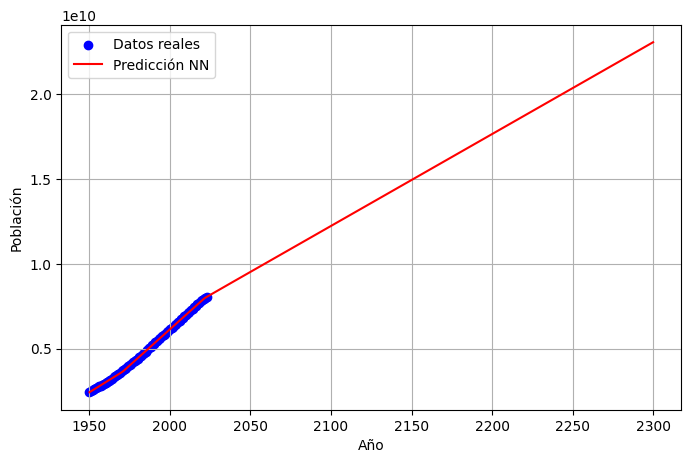

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Input
from sklearn.preprocessing import MinMaxScaler

# --- Cargar datos ---
x = np.array(x).reshape(-1, 1).astype(float)
y = np.array(y).reshape(-1, 1).astype(float)

# --- Escaladores ---
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

x_scaled = scaler_x.fit_transform(x)
y_scaled = scaler_y.fit_transform(y)

# --- Crear modelo ---
model = Sequential([
    Input(shape=(1,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1,activation='linear')
])

model.compile(optimizer='adam', loss='mse')

# --- Entrenar ---
model.fit(x_scaled, y_scaled, epochs=500, verbose=0)

# --- Predicciones ---
x_pred = np.arange(1950, 2301).reshape(-1, 1).astype(float)
x_pred_scaled = scaler_x.transform(x_pred)

y_pred_scaled = model.predict(x_pred_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# --- Graficar ---
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', label='Datos reales')
plt.plot(x_pred, y_pred, color='red', label='Predicción NN')
plt.xlabel('Año')
plt.ylabel('Población')
plt.legend()
plt.grid(True)
plt.show()


## Comparación de predicciones hasta el año 2300 (Logística, RK4, Euler y Red Neuronal)

C:\Users\mateo\AppData\Local\Temp\ipykernel_25388\805169636.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y0 = float(y[0])
C:\Users\mateo\AppData\Local\Temp\ipykernel_25388\805169636.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x0 = int(x[0])


📊 Predicciones de población mundial en 2300 (aprox.):
   • Ecuación logística: 13,599,675,808 habitantes
   • Euler (h=1):       13,600,175,061 habitantes
   • Runge–Kutta 4 (h=1): 13,599,675,808 habitantes
   • Red neuronal:        23,025,831,936 habitantes


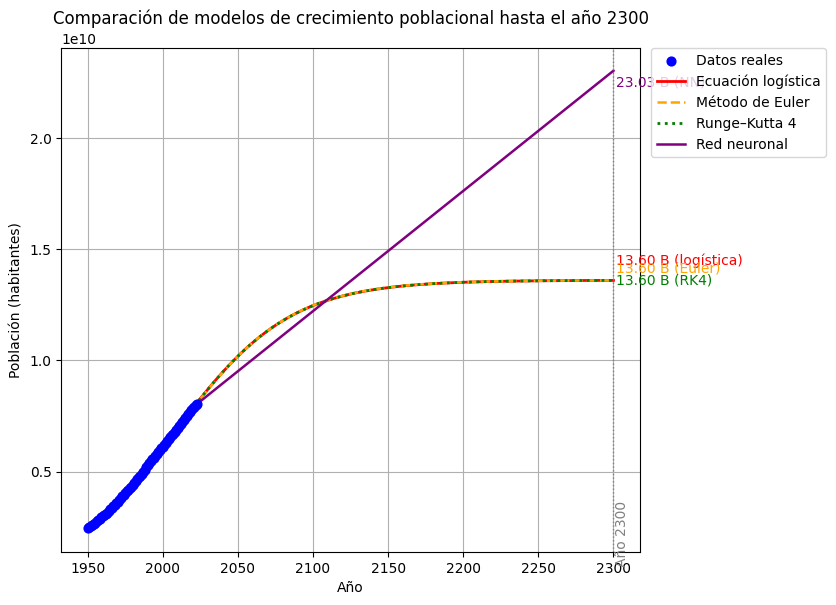

In [6]:


import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros del modelo ---
k = k_opt
r = r_opt
y0 = float(y[0])
x0 = int(x[0])

# --- Función analítica ---
def solucion_analitica(t, k, r, y0, x0):
    return (y0 * k) / (y0 + (k - y0) * np.exp(-r * (t - x0)))

# --- 1. Logística analítica ---
t_analitico = np.arange(x0, 2301)
y_analitico = solucion_analitica(t_analitico, k, r, y0, x0)

# --- 2. Euler ---
h = 1
t_euler, y_euler = metodo_euler(f, y0, [x0, 2300], h, k, r)

# --- 3. Runge-Kutta 4 ---
t_rk4, y_rk4 = metodo_rk4(f, y0, [x0, 2300], h, k, r)

# --- 4. Red neuronal ---
x_pred = np.arange(x0, 2301).reshape(-1, 1).astype(float)
x_pred_scaled = scaler_x.transform(x_pred)
y_pred_scaled = model.predict(x_pred_scaled, verbose=0)
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

# --- 5. Predicciones para 2300 ---
p2300_logistica = float(solucion_analitica(2300, k, r, y0, x0))
p2300_euler = float(y_euler[-1])
p2300_rk4 = float(y_rk4[-1])
p2300_nn = float(y_pred[-1])

print("📊 Predicciones de población mundial en 2300 (aprox.):")
print(f"   • Ecuación logística: {p2300_logistica:,.0f} habitantes")
print(f"   • Euler (h={h}):       {p2300_euler:,.0f} habitantes")
print(f"   • Runge–Kutta 4 (h={h}): {p2300_rk4:,.0f} habitantes")
print(f"   • Red neuronal:        {p2300_nn:,.0f} habitantes")

# --- 6. Gráfica ---
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x, y, label='Datos reales', color='blue', s=40, zorder=5)
ax.plot(t_analitico, y_analitico, 'r-', label='Ecuación logística', linewidth=2)
ax.plot(t_euler, y_euler, '--', color='orange', label='Método de Euler', linewidth=1.8)
ax.plot(t_rk4, y_rk4, ':', color='green', label='Runge–Kutta 4', linewidth=2)
ax.plot(x_pred.flatten(), y_pred, '-', color='purple', label='Red neuronal', linewidth=1.8)

# Línea vertical del año 2300
ax.axvline(2300, color='gray', linestyle=':', linewidth=1)
ax.text(2301, plt.ylim()[1]*0.03, 'Año 2300', rotation=90, va='bottom', color='gray')

offset = (plt.ylim()[1] - plt.ylim()[0]) * 0.015
ax.text(2302, p2300_logistica + 2*offset, f"{p2300_logistica/1e9:.2f} B (logística)", color='r')
ax.text(2302, p2300_euler + 1*offset, f"{p2300_euler/1e9:.2f} B (Euler)", color='orange')
ax.text(2302, p2300_rk4 - 0.5*offset, f"{p2300_rk4/1e9:.2f} B (RK4)", color='green')
ax.text(2302, p2300_nn - 2*offset, f"{p2300_nn/1e9:.2f} B (NN)", color='purple')

# Etiquetas y título
ax.set_xlabel('Año')
ax.set_ylabel('Población (habitantes)')
ax.set_title('Comparación de modelos de crecimiento poblacional hasta el año 2300')
ax.grid(True)

ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0, frameon=True)

plt.tight_layout(rect=[0, 0, 0.85, 1]) 
plt.show()
